# 03 — Imbalance Experiment

## Purpose
Evaluate all RAC scoring variants under genuine database-level minority class
scarcity, simulated by building subsampled ChromaDB collections at controlled
majority:minority ratios.

## Approach
For each ratio in `[2, 3, 5, 10]`, a pair of subsampled ChromaDB collections
is built from the fully populated source database. **Majority class records
(Blue, Black) are kept intact. Minority class records (Green, TTR) are
subsampled down** to `floor(min_majority_count / ratio)` per class.

All scoring variants are then evaluated against these subsampled collections
using the standard test set — no retrieval-time filtering is applied.

This design reflects real-world deployment: minority items are scarce because
they were never collected in sufficient quantities, not because majority items
were artificially removed. It is a strictly harder stress test for the DNDS
density correction than retrieval-time filtering, because the scoring function
must identify minority queries against a naturally majority-dominated neighborhood.

## Inputs
- `dataset/CVPR_2024_dataset_Test/` — test images
- `dataset_text/test.csv` — test labels and filenames
- `chroma_db/` — fully populated source collections (treated as read-only)

## Outputs
- `results/phase2/imbalance_results.json`
- `results/phase2/imbalance_summary.csv`
- `figures/phase2/minority_f1_vs_imbalance.png`

In [1]:
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from pathlib import Path
import time
import numpy as np

sys.path.insert(0, str(Path("../..").resolve()))

from tqdm.auto import tqdm

from src.phase2.config import get_phase2_config
from src.phase2.data_utils import build_records_from_csv
from src.phase2.db_client import (
    get_class_counts,
    get_image_collection,
    get_persistent_client,
    get_text_collection,
)
from src.phase2.evaluation import (
    compute_metrics,
    load_image_as_numpy,
    save_imbalance_summary_csv,
    save_results,
)
from src.phase2.gpu_utils import (
    get_device,
    print_device_info,
)
from src.phase2.imbalance import (
    infer_class_groups,
    build_imbalanced_collections,
    get_imbalanced_collection_names,
    teardown_imbalanced_collections,
)
from src.phase2.scoring import (
    global_dnds,
    idw,
    kde_dnds,
    local_dnds,
    majority_vote,
)
from src.phase2.visualization import plot_minority_f1_vs_imbalance

CONFIG = get_phase2_config()

# Per-notebook controls
PREFER_GPU = True

# Parallel imbalance controls
PARALLEL_IMBALANCE = True
IMBALANCE_MAX_WORKERS = 10

# Progress logging controls
SHOW_NOTEBOOK_PROGRESS = False
IMBALANCE_LOG_INTERVAL = 250

DEVICE = get_device(prefer_gpu=PREFER_GPU)

REPO_ROOT = Path("../..").resolve()
TEST_DIR = REPO_ROOT / "dataset" / "CVPR_2024_dataset_Test"
TEST_CSV = REPO_ROOT / "dataset_text" / "test.csv"
RESULTS_PATH = REPO_ROOT / "results" / "phase2" / "imbalance_results.json"
IMBALANCE_CSV_PATH = REPO_ROOT / "results" / "phase2" / "imbalance_summary.csv"
IMBALANCE_LOG_PATH = REPO_ROOT / "results" / "phase2" / "imbalance_experiment.log"
FIG_PATH = REPO_ROOT / "figures" / "phase2" / "minority_f1_vs_imbalance.png"
IMBALANCE_DB_PATH = REPO_ROOT / "chroma_db_imbalanced"

IMBALANCE_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
IMBALANCE_LOG_PATH.write_text("", encoding="utf-8")

print_device_info(DEVICE)
print(f"Imbalance progress log: {IMBALANCE_LOG_PATH}")

d:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU (4.00 GB VRAM, allocated 0.00 GB, reserved 0.00 GB)
Imbalance progress log: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\imbalance_experiment.log


In [2]:
test_samples, missing_examples, total_rows = build_records_from_csv(
    csv_path=TEST_CSV,
    split_dir=TEST_DIR,
    text_column="text",
    label_column="label",
    text_key="text",
)

if missing_examples:
    print("Skipped test rows with missing image files (up to 10 shown):")
    for item in missing_examples:
        print(f"  - {item}")

if not test_samples:
    raise RuntimeError("No test samples found after image path resolution.")

print(
    f"Test samples available for imbalance experiment: {len(test_samples)} / {total_rows}"
)

client = get_persistent_client(str(REPO_ROOT / "chroma_db"))
image_collection = get_image_collection(client)
text_collection = get_text_collection(client)

image_class_counts = get_class_counts(image_collection)
majority_classes, minority_classes = infer_class_groups(
    image_class_counts, threshold=float(CONFIG["majority_threshold"])
)
CONFIG["majority_classes"] = majority_classes
CONFIG["minority_classes"] = minority_classes
print(
    f"Dynamic class grouping -> majority: {majority_classes}, minority: {minority_classes}"
)

variants = {
    "majority_vote": majority_vote,
    "idw": idw,
    "global_dnds": global_dnds,
    "local_dnds": local_dnds,
    "kde_dnds": kde_dnds,
}

# Separate ChromaDB client for imbalanced collections
# Source collections in chroma_db/ are never modified
imbalanced_client = get_persistent_client(str(IMBALANCE_DB_PATH))

print("\n=== Imbalance Experiment Setup ===")
print(f"Source DB class counts: {image_class_counts}")
print(f"Majority classes (kept intact):      {CONFIG['majority_classes']}")
print(f"Minority classes (to be subsampled): {CONFIG['minority_classes']}")
print(f"Imbalance ratios: {CONFIG['imbalance_ratios']}")

majority_min = min(
    image_class_counts[c] for c in CONFIG["majority_classes"] if c in image_class_counts
)
print("\nExpected minority targets per class:")
for ratio in CONFIG["imbalance_ratios"]:
    target = max(1, majority_min // ratio)
    print(f"  ratio={ratio}:1 -> {target} records per minority class")

Test samples available for imbalance experiment: 3452 / 3452


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1318.11it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dynamic class grouping -> majority: ['Blue'], minority: ['Black', 'Green', 'TTR']

=== Imbalance Experiment Setup ===
Source DB class counts: {'Blue': 4856, 'Green': 2331, 'Black': 2382, 'TTR': 2116}
Majority classes (kept intact):      ['Blue']
Minority classes (to be subsampled): ['Black', 'Green', 'TTR']
Imbalance ratios: [2, 3, 5, 10]

Expected minority targets per class:
  ratio=2:1 -> 2428 records per minority class
  ratio=3:1 -> 1618 records per minority class
  ratio=5:1 -> 971 records per minority class
  ratio=10:1 -> 485 records per minority class


In [3]:
all_results = {
    "ratios": CONFIG["imbalance_ratios"],
    "variants": {k: {} for k in variants.keys()},
}

TEARDOWN_AFTER_RATIO = True
PARALLEL_BY_RATIO = True
RATIO_MAX_WORKERS = 2


def _log_progress(message: str) -> None:
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with IMBALANCE_LOG_PATH.open("a", encoding="utf-8") as handle:
        handle.write(f"[{timestamp}] {message}\n")


def _coerce_query_text(value) -> str:
    if value is None:
        return ""
    if isinstance(value, float) and np.isnan(value):
        return ""
    return str(value)


def _evaluate_single_ratio(ratio: int) -> tuple[str, dict[str, dict]]:
    print(f"\n{'='*60}")
    print(f"RATIO {ratio}:1")
    print(f"{'='*60}")
    _log_progress(f"START ratio {ratio}:1")

    ratio_client = get_persistent_client(str(IMBALANCE_DB_PATH))

    imb_image_col, imb_text_col = build_imbalanced_collections(
        client=ratio_client,
        source_image_collection=image_collection,
        source_text_collection=text_collection,
        majority_classes=CONFIG["majority_classes"],
        minority_classes=CONFIG["minority_classes"],
        ratio=ratio,
        image_collection_name=get_imbalanced_collection_names(ratio)[0],
        text_collection_name=get_imbalanced_collection_names(ratio)[1],
        seed=42,
    )

    ratio_results: dict[str, dict] = {}

    for name, fn in variants.items():
        _log_progress(f"START {name} @ {ratio}:1")

        y_true: list[str] = []
        y_pred: list[str] = []
        latencies: list[float] = []

        iterator = (
            enumerate(tqdm(test_samples, desc=f"{name} @ {ratio}:1"), start=1)
            if not PARALLEL_BY_RATIO
            else enumerate(test_samples, start=1)
        )

        for sample_index, sample in iterator:
            query_image = load_image_as_numpy(sample["image_path"])
            query_text = _coerce_query_text(sample.get("text"))
            t0 = time.perf_counter()
            pred = fn(
                query_image=query_image,
                query_text=query_text,
                image_collection=imb_image_col,
                text_collection=imb_text_col,
                config=CONFIG,
                alpha=CONFIG["alpha"],
            )
            latencies.append((time.perf_counter() - t0) * 1000.0)
            y_true.append(sample["label"])
            y_pred.append(pred)

            if sample_index % IMBALANCE_LOG_INTERVAL == 0 or sample_index == len(
                test_samples
            ):
                _log_progress(
                    f"{name} @ {ratio}:1 progress {sample_index}/{len(test_samples)}"
                )

        metrics = compute_metrics(y_true, y_pred, CONFIG["class_names"])
        metrics["inference_time_ms"] = float(np.mean(latencies))
        ratio_results[name] = metrics
        _log_progress(f"DONE {name} @ {ratio}:1")

    if TEARDOWN_AFTER_RATIO:
        print(f"\nTearing down imbalanced collections for ratio {ratio}:1 ...")
        teardown_imbalanced_collections(ratio_client, ratio)

    _log_progress(f"DONE ratio {ratio}:1")
    return str(ratio), ratio_results


ratios = list(CONFIG["imbalance_ratios"])
if PARALLEL_BY_RATIO and len(ratios) > 1:
    workers = max(1, min(RATIO_MAX_WORKERS, len(ratios)))
    print(f"Running ratios in parallel with {workers} workers.")
    _log_progress(f"RUN ratios in parallel workers={workers}")

    with ThreadPoolExecutor(max_workers=workers) as pool:
        future_map = {
            pool.submit(_evaluate_single_ratio, ratio): ratio for ratio in ratios
        }
        for future in as_completed(future_map):
            ratio = future_map[future]
            ratio_key, ratio_metrics = future.result()
            for variant_name, metrics in ratio_metrics.items():
                all_results["variants"][variant_name][ratio_key] = metrics
            print(f"Completed ratio {ratio}:1")
            _log_progress(f"COMPLETED ratio {ratio}:1")
else:
    _log_progress("RUN ratios sequentially")
    for ratio in ratios:
        ratio_key, ratio_metrics = _evaluate_single_ratio(ratio)
        for variant_name, metrics in ratio_metrics.items():
            all_results["variants"][variant_name][ratio_key] = metrics

Running ratios in parallel with 2 workers.

RATIO 2:1

RATIO 3:1
Ratio 2:1 - minority target per class: 2428
  Majority counts kept intact: {'Blue': 4856}
  Minority classes will be subsampled to: 2428
Ratio 3:1 - minority target per class: 1618
  Majority counts kept intact: {'Blue': 4856}
  Minority classes will be subsampled to: 1618

Built imbalanced collections at ratio 3:1
  Image DB - Blue: 4856 records
  Image DB - Black: 1618 records
  Image DB - Green: 1618 records
  Image DB - TTR: 1618 records
  Actual ratio Blue:Black = 3.00:1 (target 3:1)
  Actual ratio Blue:Green = 3.00:1 (target 3:1)
  Actual ratio Blue:TTR = 3.00:1 (target 3:1)

Built imbalanced collections at ratio 2:1
  Image DB - Blue: 4856 records
  Image DB - Black: 2382 records
  Image DB - Green: 2331 records
  Image DB - TTR: 2116 records
  Actual ratio Blue:Black = 2.04:1 (target 2:1)
  Actual ratio Blue:Green = 2.08:1 (target 2:1)
  Actual ratio Blue:TTR = 2.29:1 (target 2:1)

Tearing down imbalanced collecti

Saved JSON results: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\imbalance_results.json
Saved CSV summary: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\results\phase2\imbalance_summary.csv
Saved figure: D:\University of Calgary\Winter 2026\ENSF617-Introduction-To-Machine-Learning\trash-classification-project\figures\phase2\minority_f1_vs_imbalance.png


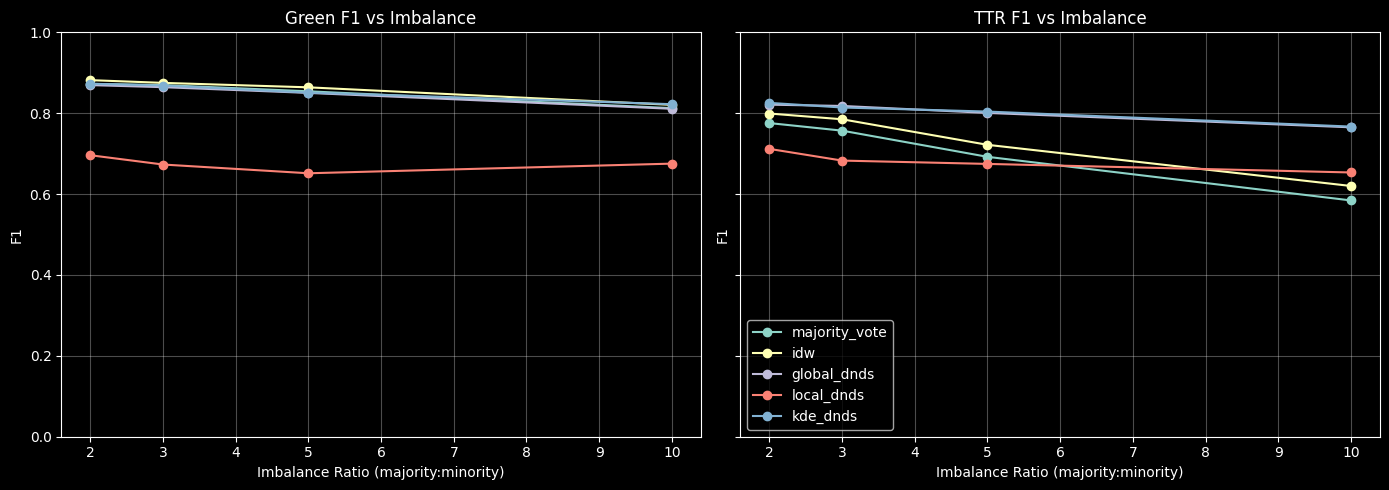

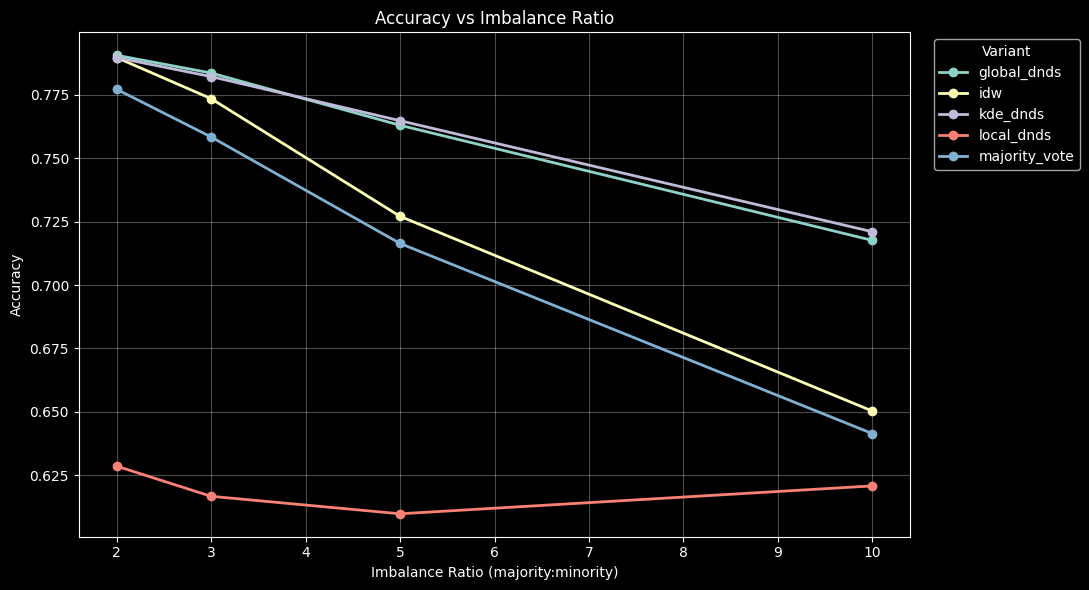

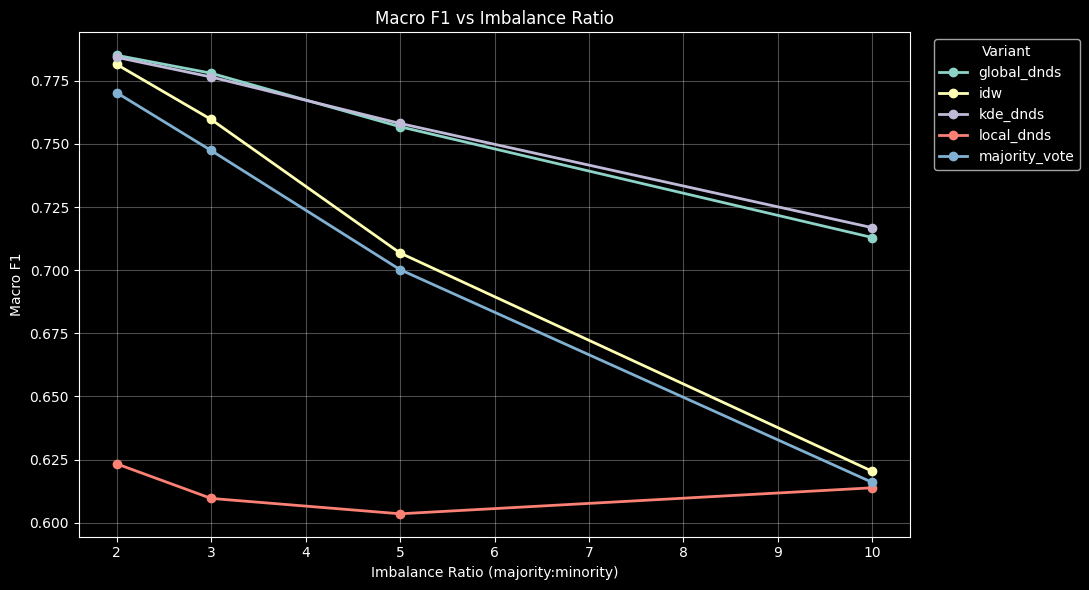

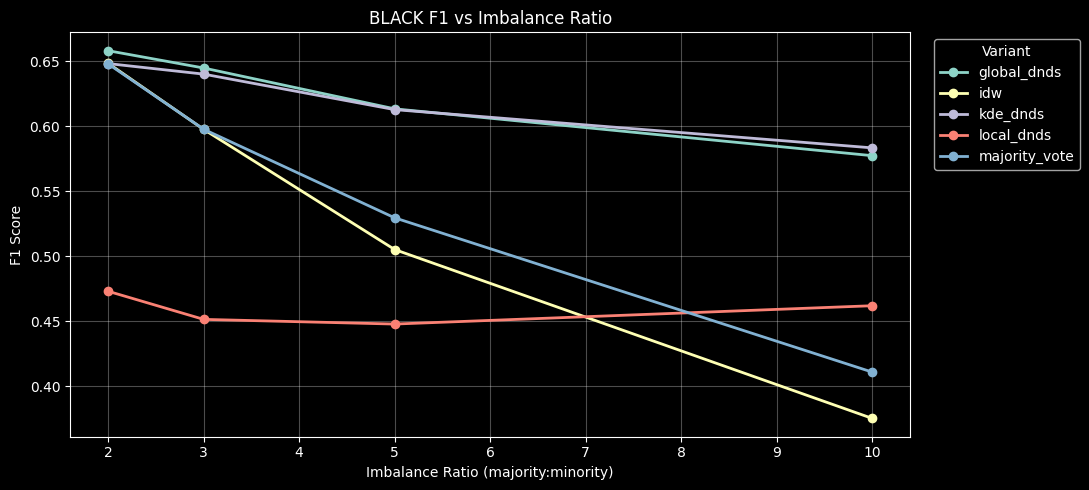

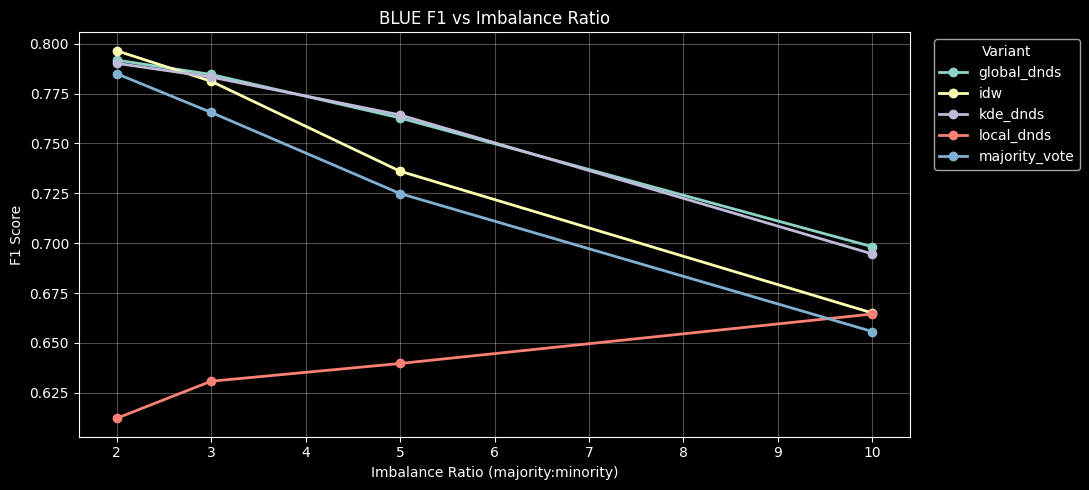

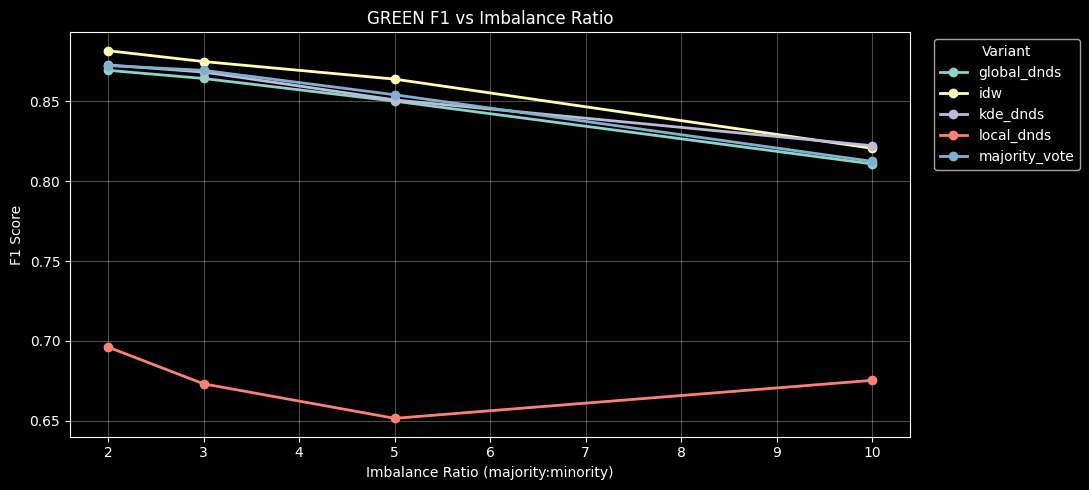

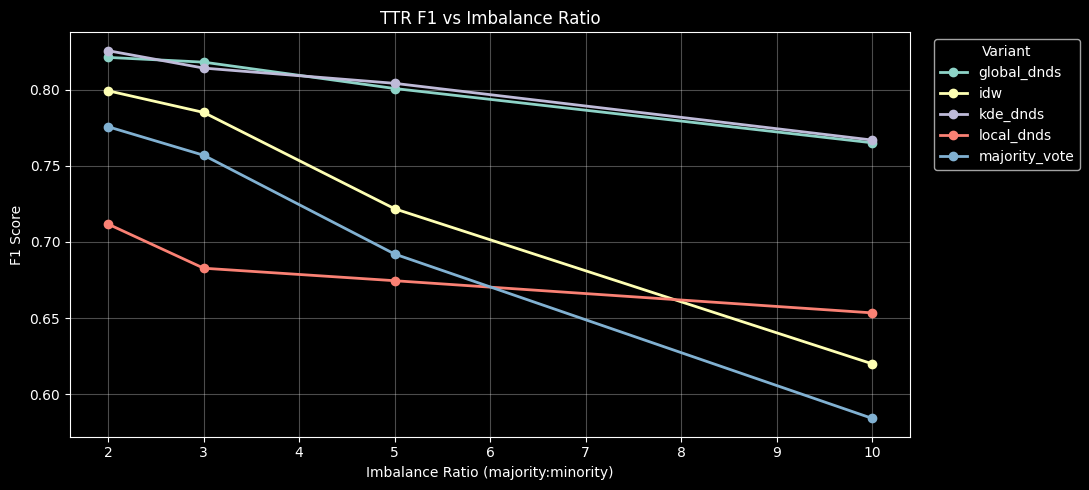


IMBALANCE RESULTS SUMMARY TABLE
    ratio        variant  accuracy  macro_f1  black_f1  blue_f1  green_f1  \
0       2    global_dnds    0.7906    0.7851    0.6582   0.7918    0.8695   
1       2            idw    0.7897    0.7815    0.6485   0.7965    0.8818   
2       2       kde_dnds    0.7897    0.7843    0.6483   0.7902    0.8729   
3       2     local_dnds    0.6286    0.6233    0.4732   0.6122    0.6961   
4       2  majority_vote    0.7772    0.7703    0.6480   0.7850    0.8725   
5       3    global_dnds    0.7836    0.7780    0.6449   0.7846    0.8644   
6       3            idw    0.7735    0.7597    0.5977   0.7812    0.8750   
7       3       kde_dnds    0.7822    0.7765    0.6402   0.7833    0.8684   
8       3     local_dnds    0.6167    0.6096    0.4516   0.6308    0.6731   
9       3  majority_vote    0.7584    0.7474    0.5978   0.7656    0.8695   
10      5    global_dnds    0.7630    0.7568    0.6135   0.7628    0.8502   
11      5            idw    0.7271    0.706

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

save_results(all_results, str(RESULTS_PATH))
save_imbalance_summary_csv(all_results, str(IMBALANCE_CSV_PATH))
plot_minority_f1_vs_imbalance(all_results, str(FIG_PATH))

print(f"Saved JSON results: {RESULTS_PATH}")
print(f"Saved CSV summary: {IMBALANCE_CSV_PATH}")
print(f"Saved figure: {FIG_PATH}")

# Tabular summary for quick inspection
rows = []
for ratio in all_results.get("ratios", []):
    ratio_key = str(ratio)
    for variant_name, by_ratio in all_results.get("variants", {}).items():
        metrics = by_ratio.get(ratio_key, {})
        per_f1 = metrics.get("per_class_f1", {})
        rows.append(
            {
                "ratio": ratio,
                "variant": variant_name,
                "accuracy": round(float(metrics.get("accuracy", 0.0)), 4),
                "macro_f1": round(float(metrics.get("macro_f1", 0.0)), 4),
                "black_f1": round(float(per_f1.get("Black", 0.0)), 4),
                "blue_f1": round(float(per_f1.get("Blue", 0.0)), 4),
                "green_f1": round(float(per_f1.get("Green", 0.0)), 4),
                "ttr_f1": round(float(per_f1.get("TTR", 0.0)), 4),
            }
        )

summary_df = pd.DataFrame(rows).sort_values(["ratio", "variant"]).reset_index(drop=True)

# Plot 1: Accuracy by ratio and variant
accuracy_pivot = summary_df.pivot(index="ratio", columns="variant", values="accuracy")
plt.figure(figsize=(11, 6))
for variant_name in accuracy_pivot.columns:
    plt.plot(
        accuracy_pivot.index,
        accuracy_pivot[variant_name],
        marker="o",
        linewidth=2,
        label=variant_name,
    )
plt.xlabel("Imbalance Ratio (majority:minority)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Imbalance Ratio")
plt.grid(alpha=0.3)
plt.legend(title="Variant", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot 2: Macro F1 by ratio and variant
macro_pivot = summary_df.pivot(index="ratio", columns="variant", values="macro_f1")
plt.figure(figsize=(11, 6))
for variant_name in macro_pivot.columns:
    plt.plot(
        macro_pivot.index,
        macro_pivot[variant_name],
        marker="o",
        linewidth=2,
        label=variant_name,
    )
plt.xlabel("Imbalance Ratio (majority:minority)")
plt.ylabel("Macro F1")
plt.title("Macro F1 vs Imbalance Ratio")
plt.grid(alpha=0.3)
plt.legend(title="Variant", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot 3: Class-wise F1 (Black, Blue, Green, TTR)
class_f1_cols = ["black_f1", "blue_f1", "green_f1", "ttr_f1"]
classwise_long = summary_df.melt(
    id_vars=["ratio", "variant"],
    value_vars=class_f1_cols,
    var_name="class",
    value_name="f1",
)
classwise_long["class"] = classwise_long["class"].str.replace("_f1", "").str.upper()

for cls in ["BLACK", "BLUE", "GREEN", "TTR"]:
    cls_df = classwise_long[classwise_long["class"] == cls]
    cls_pivot = cls_df.pivot(index="ratio", columns="variant", values="f1")

    plt.figure(figsize=(11, 5))
    for variant_name in cls_pivot.columns:
        plt.plot(
            cls_pivot.index,
            cls_pivot[variant_name],
            marker="o",
            linewidth=2,
            label=variant_name,
        )
    plt.xlabel("Imbalance Ratio (majority:minority)")
    plt.ylabel("F1 Score")
    plt.title(f"{cls} F1 vs Imbalance Ratio")
    plt.grid(alpha=0.3)
    plt.legend(title="Variant", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
print("IMBALANCE RESULTS SUMMARY TABLE")
print("=" * 80)
print(summary_df)